# Differenz between row-Data and Normalize-Data:

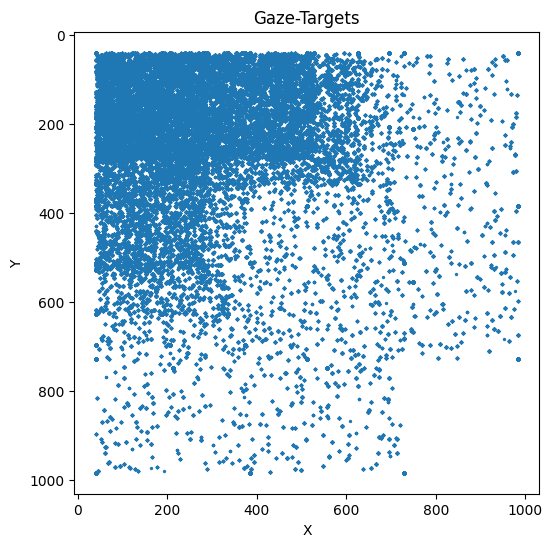



X_min: 0.0390625	 X_max: 1.0
Y_min: 0.0390625	 Y_max: 1.0 




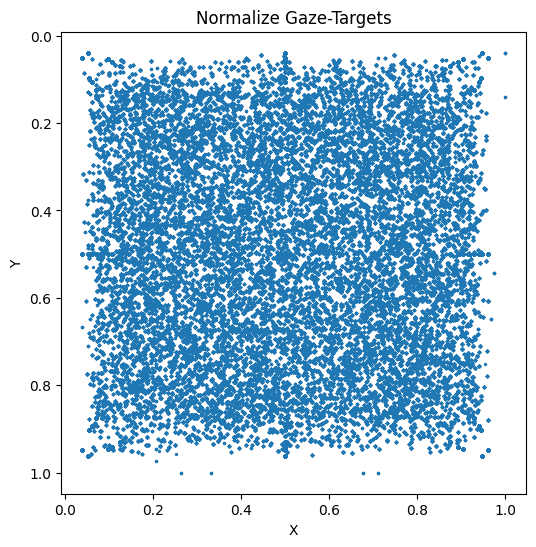

In [37]:
# PLOT:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



labels_file = "./dataset/labels.csv"

df = pd.read_csv(labels_file)

# print(df.head())
# print("Anzahl Samples:", len(df))

x = df["x"]
y = df["y"]

# print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
# print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()





# Normalize:

norm_labels_file = './dataset/norm_labels.csv'

df2 = pd.read_csv(norm_labels_file)

x = df2["x"]
y = df2["y"]

print(f"\n\nX_min: {np.min(x)}\t X_max: {np.max(x)}")
print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)} \n\n")
"""
df = pd.read_csv("./dataset/norm_labels.csv")

errors = df[(df["x_norm"] > 1) | (df["y_norm"] > 1)]

print(errors)
"""

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Normalize Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()

# Baseline (Random and Constant):

In [14]:
# Normalization: 

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: -------------------------------
# -------------------------------------------------------------------

print("\nNormalization: \n")
norm_labels_file = './dataset/norm_labels.csv'
df2 = pd.read_csv(norm_labels_file)



x_true = df2["x"].values
y_true = df2["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

# x_const = 0.5
# y_const = 0.5

print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

print("\nKonstant Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
# print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


# -------------------------------------------------------------------
# ---------------------- Random-Error -------------------------------
# -------------------------------------------------------------------

x = df2["x"]
y = df2["y"]
x_max = np.max(x)
x_min = np.min(x)
y_max = np.max(y)
y_min = np.min(y)

# x_max = 1.0
# y_max = 1.0


pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
# print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} % \n\n")


if globals().get("bas_const_err") is None:
    bas_const_err = const_diagonal_error_pct

if globals().get("bas_rand_err") is None:
    bas_rand_err = random_diagonal_error_pct

# print(f"\n\n bas_rand_error: {bas_const_err}\n bas_const_error: {bas_rand_err}")



Normalization: 

x_const: 0.5018271047520313
y_const: 0.5004797436472681

Konstant Baseline:

Constant_Mean_Absolute_Error: 0.35649399675432236
Constant_Mean_Squared_Error: 0.3852981815765823
Constant_Diagonal-Error %: 27.2447 %

Random Baseline:

Random_Mean_Absolute_Error: 0.4969371612297855
Random_Mean_Squared_Error: 0.5506683308361926
Random_Diagonal-Error %: 38.93813 % 




In [70]:
# 1: Bib

import time
# start_time = time.perf_counter()

import os
import re
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter



In [71]:

# 2: Dataset Class: transfer CSV in PyTorch.
class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None, read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size = dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images = torch.zeros([self.dataset_size] + list(out.shape))
            self.targets = torch.zeros(self.dataset_size, 2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx] = image

    def __len__(self):

        return self.dataset_size

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]

In [112]:
class GazeVisualizer:
    
    def plot_ground_truth(self, targets):

        diagram_dir = "results/dataset/diagrams/"
        
        if not os.path.exists(diagram_dir):
            os.makedirs(diagram_dir, 
                        exist_ok=True
                       )
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            targets[:,0],
            targets[:,1],
            s=8
        )
        
        plt.title("Ground Truth")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid()
        plt.savefig(
            f"{diagram_dir}ground_truth_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        

    def plot_predictions(self, predictions):

        diagram_dir = "results/dataset/diagrams/"
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            s=8
        )
        
        plt.title("Prediction")
        plt.grid()
        plt.savefig(
            f"{diagram_dir}predictions_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()

    
    def plot_comparison(self, predictions, targets):

        diagram_dir = "results/dataset/diagrams/"
        
        plt.figure(figsize=(7,7))
        
        plt.scatter(
            targets[:,0],
            targets[:,1],
            color="red",
            s=15,
            label="Ground Truth"
        )
        
        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            color="blue",
            s=15,
            label="Prediction"
        )
        
        for i in range(len(targets)):
            plt.plot(
                [targets[i,0], predictions[i,0]],
                [targets[i,1], predictions[i,1]],
                color="gray",
                alpha=0.2
            )
        
        plt.legend()
        plt.grid()

        plt.savefig(
            f"{diagram_dir}comparison_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()

    
    def plot_heatmap(self, predictions):

        diagram_dir = "results/dataset/diagrams/"

        plt.figure(figsize=(7,6))
    
        plt.hist2d(
            predictions[:,0],
            predictions[:,1],
            bins=40,
            cmap="hot"      # oder: cmap="viridis" 
        )
        
        plt.colorbar()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Prediction Heatmap")

        plt.savefig(
            f"{diagram_dir}Heatmap_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()


    
    def plot_error_heatmap(self, predictions, targets, errors):

        diagram_dir = "results/dataset/diagrams/"

        plt.figure(figsize=(7,6))

        plt.scatter(
            targets[:,0],
            targets[:,1],
            c=errors,
            cmap="viridis",
            s=30
        )

        plt.scatter(        
            targets[:,0],
            targets[:,1],
            c=errors,
            cmap="jet"
        
        )
        
        plt.colorbar()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Prediction Heatmap")
        plt.savefig(
            f"{diagram_dir}Error-Heatmap_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
            
        plt.show()


        
    def animate_predictions(self, predictions, targets):

        diagram_dir = "results/dataset/diagrams/"


        plt.figure(figsize=(7,7))
        plt.ion()

        pred_x = []
        pred_y = []
        
        for i in range(len(predictions)):
        
            pred_x.append(predictions[i,0])
            pred_y.append(predictions[i,1])
        
            plt.clf()
        
            plt.scatter(
                pred_x,
                pred_y,
                s=8
            )
        
            plt.scatter(
                targets[i,0],
                targets[i,1],
                c="red",
                s=80
            )
        
            plt.pause(0.01)

        
        plt.ioff()
        plt.show()


In [73]:

# 5: func-Diagonal-Error:
def diagonal_errors(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    mae = mean_absolute_error(targets, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)


    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [74]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )


    return targets, predictions, errors

In [75]:
class GaussianActivation(nn.Module):

    def __init__(self, sigma=1.0):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        return torch.exp(
            -(x ** 2) / (2 * self.sigma ** 2)
        )

In [87]:
# Hypoparameter:

# def_dataset_size = [10000, 2000]
def_dataset_size = [1000, 200]

optimizer_name = "AdamW"
batch_Size = 64


epochs = 25
# epochs = 2

# learning_rate = 1e-4
learning_rate = 1e-5
weight_Decay = 1e-5

active_func = None

# patience = 2               # after 2 Epochen without Optimierung has to stop training
patience = 3               # after 3 Epochen without Optimierung has to stop training


In [88]:
# 6: CSV laden
df = pd.read_csv("dataset/norm_labels.csv")
df.head()
# check:
# print(df.shape)

,image_name,x,y,subject_ID,screen_w,screen_h
0,dataset/images/00002/00002/frames/00000.jpg,0.500000,0.500000,2,320,568
1,dataset/images/00002/00002/frames/00001.jpg,0.500000,0.500000,2,320,568
2,dataset/images/00002/00002/frames/00002.jpg,0.500000,0.500000,2,320,568
3,dataset/images/00002/00002/frames/00003.jpg,0.500000,0.500000,2,320,568
4,dataset/images/00002/00002/frames/00004.jpg,0.873929,0.114375,2,320,568


In [7]:
# 7: check a image
# row = df.iloc[0]
# img = Image.open(row["image_name"])
# plt.imshow(img)
# plt.show()
# print(row["x"], row["y"])

In [89]:
# 8: DataLoader
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset:


def_dataset = 'norm_subject'

train_dataset = GazeDataset(
    "./splits/norm_subject_train.csv",
    transform, dataset_size=def_dataset_size[0],
)

test_dataset = GazeDataset(
    "./splits/norm_subject_test.csv",
    transform, dataset_size=def_dataset_size[1],
)



# def_dataset = 'norm_random'

# train_dataset = GazeDataset(
#     "./splits/norm_random_train.csv",
#     transform, dataset_size=def_dataset_size[0],
# )

# test_dataset = GazeDataset(
#     "./splits/norm_random_test.csv",
#     transform, dataset_size=def_dataset_size[1],
# )



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_Size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_Size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 93.34it/s]


In [6]:
## Test:
# datasets_file = ["./dataset/labels.csv", "./dataset/norm_labels.csv"]
# d = datasets_file[0]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())

# d = datasets_file[1]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())



# print(f" len(train_dataset): {len(train_dataset)}")
# print(f" len(test_dataset):  {len(test_dataset)}")



In [90]:
# 9: ResNet18 (Pretrainiertes Modell):
# Load:
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model_name = model.__class__.__name__

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    # GaussianActivation(sigma=1.0),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    # nn.ReLU()
    nn.Sigmoid()
)

# active_func = 'no Sigmoid, no Gaussian'
# active_func = 'only Gaussian'
# active_func = 'Gaussian and ReLU'
# active_func = 'Gaussian and Sigmoid'
active_func = 'only Sigmoid'
# active_func = 'only ReLU'


In [91]:
# 10: GPU
# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# print(device)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [92]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True

for param in model.fc.parameters():
    param.requires_grad=True


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_Decay
)

# Optimizer:
# optimizer = torch.optim.Adam(
#     # model.parameters(),
#     model.fc.parameters(),
#     lr=1e-4
# )

In [ ]:
# 12: Training

print(f"extra_act-func: {active_func}\n")

epochs = epochs
# epochs = 2

if globals().get("bas_const_err") is None:
    bas_const_err = 27.245

if globals().get("bas_rand_err") is None:
    bas_rand_err = 38.961
    

model_output = './models'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )


diag_test_error, diag_train_error = [], []

best_error = float("inf")

t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training

writer = SummaryWriter(
        log_dir=os.path.join("runs", f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}_"
                                     f"{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}")
    )

train_start = time.perf_counter()

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()

    print(f"\ntrain_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\ntest_error:")
    test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
    diag_test_error.append(np.round(test_diag_pct, 4))

    # writer.add_scalar("train_error/epoch", float(f"{train_diag_pct:.4f}"), epoch + 1)
    # writer.add_scalar("test_error/epoch", float(f"{test_diag_pct:.4f}"), epoch + 1)
    # writer.add_scalar("train_loss/epoch", running_loss / len(train_loader), epoch + 1)
    writer.add_scalars(
        main_tag="Diagnostic Error",
        tag_scalar_dict={
            "Train": f"{train_diag_pct:.4f}",
            "Test": f"{test_diag_pct:.4f}",
            "Constant": bas_const_err,
            "Random": bas_rand_err
        },
        global_step=epoch + 1
    )
    writer.flush()

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or test_diag_pct < best_error:
    
        # find an improvement
        best_error = test_diag_pct
        t = 0
        e += 1
    
        print(
            f"Test-Diagonal-Error: {test_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        torch.save(
            model.state_dict(),
            f"./models/{model_name}_the-best-model_{active_func}_"
            f"{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}.path"
        )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break



    epoch_end = time.perf_counter()


    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"test_diag_error={test_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% | \n"
    )

    torch.save(model.state_dict(),
               f"./models/{model_name}_the-last-model_{active_func}__{def_dataset}_{def_dataset_size[0]}-{def_dataset_size[1]}.path")


train_end = time.perf_counter()
end_time = time.perf_counter()

writer.add_hparams(
    {
        "dataset": def_dataset,
        "dataset_size": str(def_dataset_size),
        "optimizer": optimizer_name,
        "learning_rate": float(learning_rate),
        "weight_decay": float(weight_Decay),
        "batch_size": batch_Size,
        "epochs": epochs
    },
    {
        "hparam/test_diag_error": float(diag_test_error[-1]),
        "hparam/train_diag_error": float(diag_train_error[-1]),
        "hparam/total_running_time_min": float((end_time - start_time) / 60),
        "hparam/train_running_time_min": float((train_end - train_start) / 60)
    }
)

writer.add_text(
    tag=f"Train-Error & Test-Error for {epochs} Epochs",
    text_string=f"Train-Error: {np.float64(diag_train_error)}\n"
                f"Test-Error: {np.float64(diag_test_error)}",
    global_step=0
)

writer.flush()



# train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time / 60:.2f} Minuten\n")


# print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
# print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

end_time = time.perf_counter()
elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


extra_act-func: only Sigmoid



Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:01<00:00,  3.82s/it, loss=0.0412]



train_error:
MAE : 0.2305 	 RMSE: 0.2789 
Diagonal-Error %: 19.7205 %

test_error:
MAE : 0.2372 	 RMSE: 0.2851 
Diagonal-Error %: 20.1590 %
Test-Diagonal-Error: 20.1590% | Improvment: 1

[08:55:38] Epoch 1: 110.15 Sekunden | Running_loss: 0.039 | test_diag_error=20.1590% | train_diag_error=19.7205% | 



Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:59<00:00,  3.69s/it, loss=0.035]



train_error:
MAE : 0.2290 	 RMSE: 0.2770 
Diagonal-Error %: 19.5848 %

test_error:
MAE : 0.2376 	 RMSE: 0.2854 
Diagonal-Error %: 20.1808 %
Patience: 1/3

[08:57:27] Epoch 2: 108.65 Sekunden | Running_loss: 0.039 | test_diag_error=20.1808% | train_diag_error=19.5848% | 



Epoch 3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:58<00:00,  3.63s/it, loss=0.0354]



train_error:
MAE : 0.2279 	 RMSE: 0.2753 
Diagonal-Error %: 19.4688 %

test_error:
MAE : 0.2380 	 RMSE: 0.2857 
Diagonal-Error %: 20.1998 %
Patience: 2/3

[08:59:16] Epoch 3: 108.85 Sekunden | Running_loss: 0.038 | test_diag_error=20.1998% | train_diag_error=19.4688% | 



Epoch 4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:59<00:00,  3.75s/it, loss=0.0462]



train_error:




 Diagonal-Train-Error: [19.7205 19.5848 19.4688 19.3586]

 Diagonal-Test-Error: [20.159  20.1808 20.1998 20.2224]


 Diagonal-Train-Error-Max: 19.7205 	 Diagonal-Train-Error-Min: 19.3586	
 Diagonal-Test-Error-Max: 20.2224	 Diagonal-Test-Error-Min: 20.159	 max_needed_epochs: 1



Minimum Test Error:
Epoch:           1
Test Error:      20.1590%
Train Error:     19.7205%
Constant Error:  27.2450%
Random Error:    38.9610%



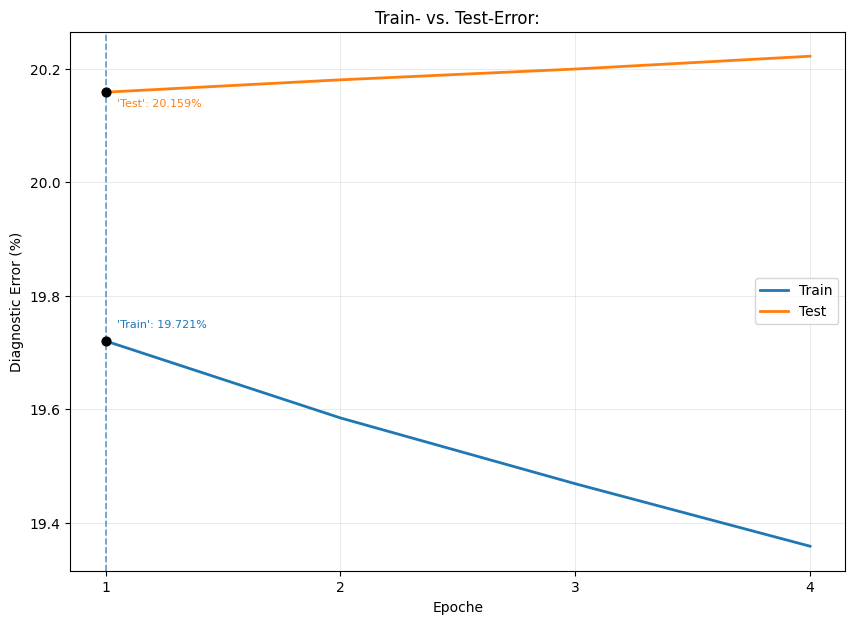

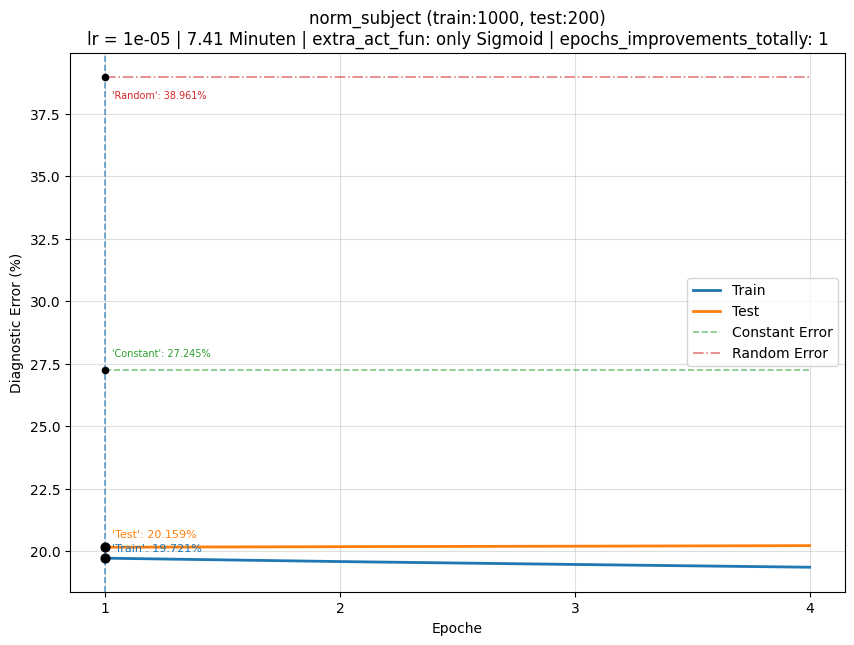

In [102]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_test_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_test_error)}\t Diagonal-Test-Error-Min: {np.min(diag_test_error)}\t max_needed_epochs: {e}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")


if globals().get("bas_const_err") is None:
    bas_const_err = 27.245

if globals().get("bas_rand_err") is None:
    bas_rand_err = 38.961

if globals().get("session") is None:
    session = 'dataset_gazecapture'

# Curven:

# Minimum Test Error bestimmen
min_test_error = min(diag_test_error)
min_test_epoch = diag_test_error.index(min_test_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_test_epoch - 1]
test_at_min = diag_test_error[min_test_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
test_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_test_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Test Error
plt.plot(epochs, diag_test_error, label="Test", linewidth=2, color=test_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=test_color,
    fontsize=8,
)


plt.title("Train- vs. Test-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Test Error
plt.plot(
    epochs,
    diag_test_error,
    label="Test",
    linewidth=2,
    color=test_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_test_epoch}")
print(f"Test Error:      {test_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_test_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=test_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_test_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_test_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{def_dataset} "
    f"(train:{def_dataset_size[0]}, test:{def_dataset_size[1]})\n"
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results/compare", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/compare/diag_error_{active_func}_{def_dataset}_{learning_rate}_{def_dataset_size[0]}_{def_dataset_size[1]}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Compare :
## active_func = 'no Sigmoid, no Gaussian'
## active_func = 'only ReLU'
## active_func = 'only Gaussian'
## active_func = 'Gaussian and ReLU'
## active_func = 'only Sigmoid'
## active_func = 'Gaussian and Sigmoid'

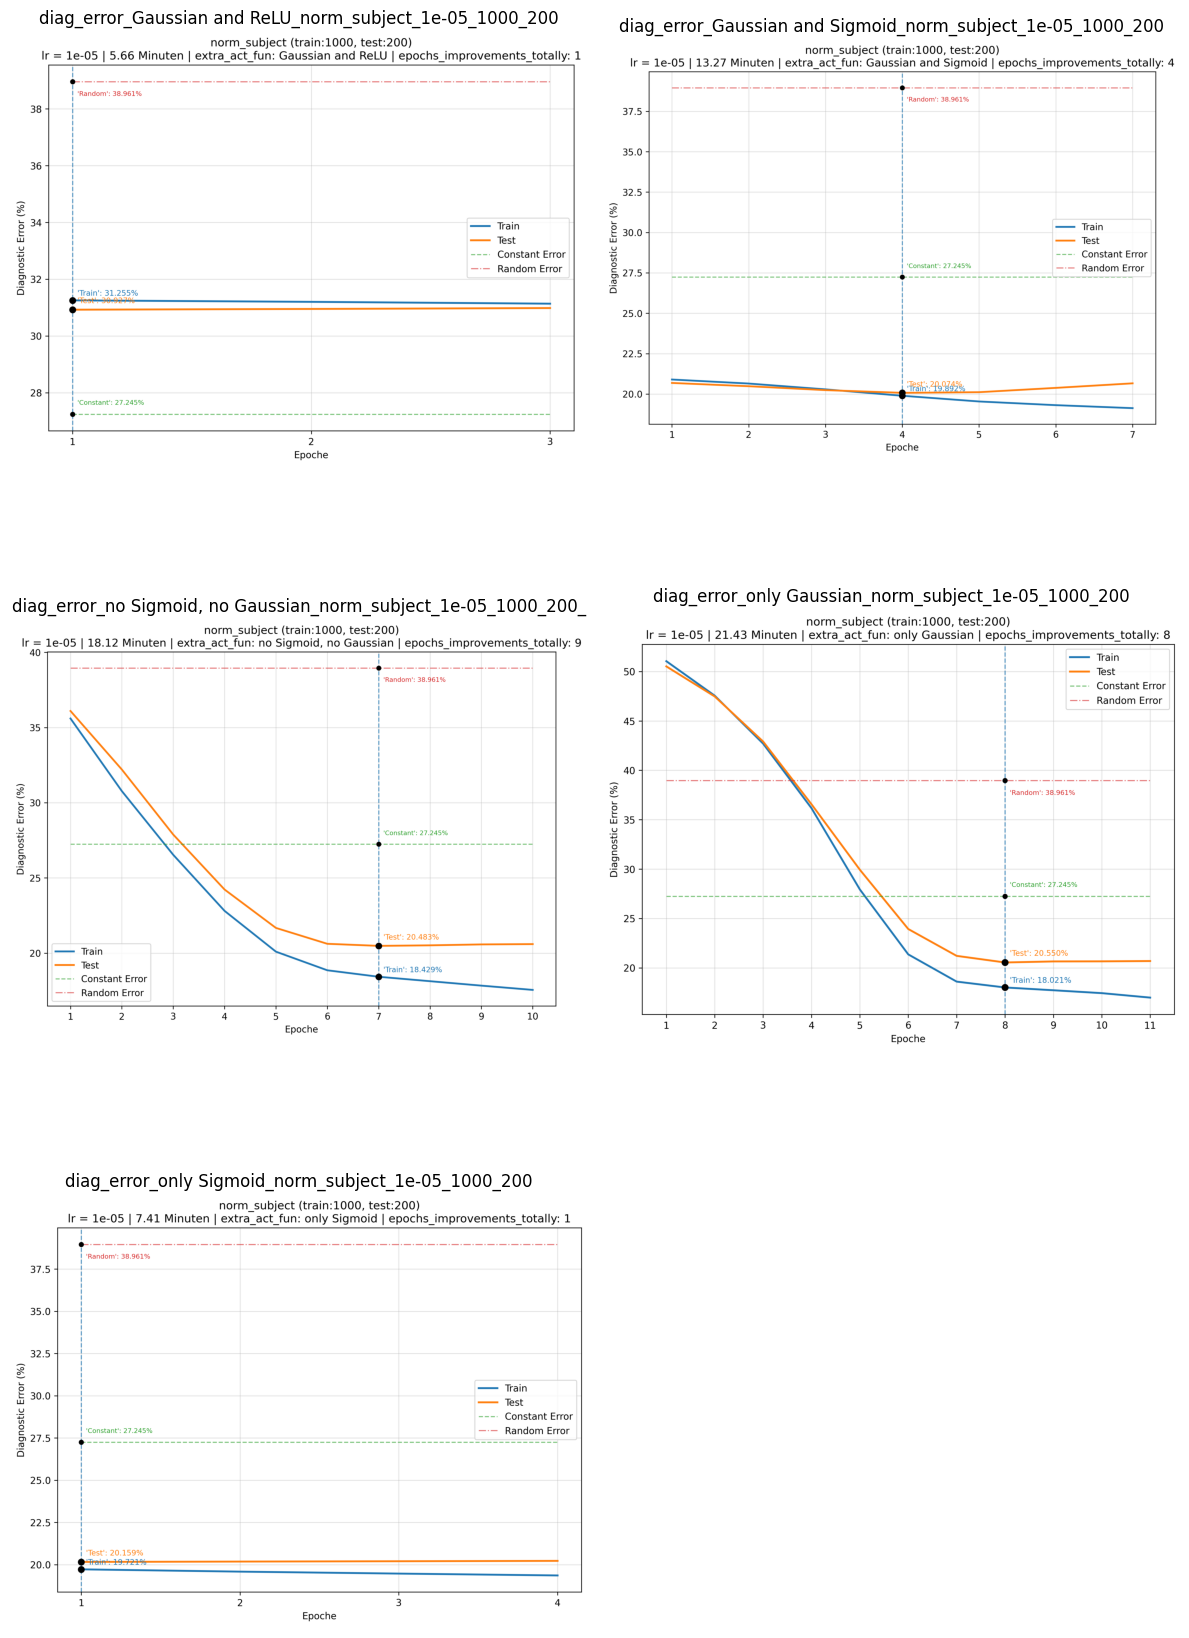

In [103]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_path = Path("./results/compare")

images = sorted(result_path.glob("*.png"))

cols = 2
rows = (len(images) + cols - 1) // cols

plt.figure(figsize=(12, 6 * rows))

for i, img_path in enumerate(images):

    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.stem)

plt.tight_layout()
plt.show()

# Compare : 
lr (1e-4 vs. 1e-5 vs. 1e-6) | 

datasets: (random_split vs. norm_subject_split) | 

train_size (1% vs 10%) 

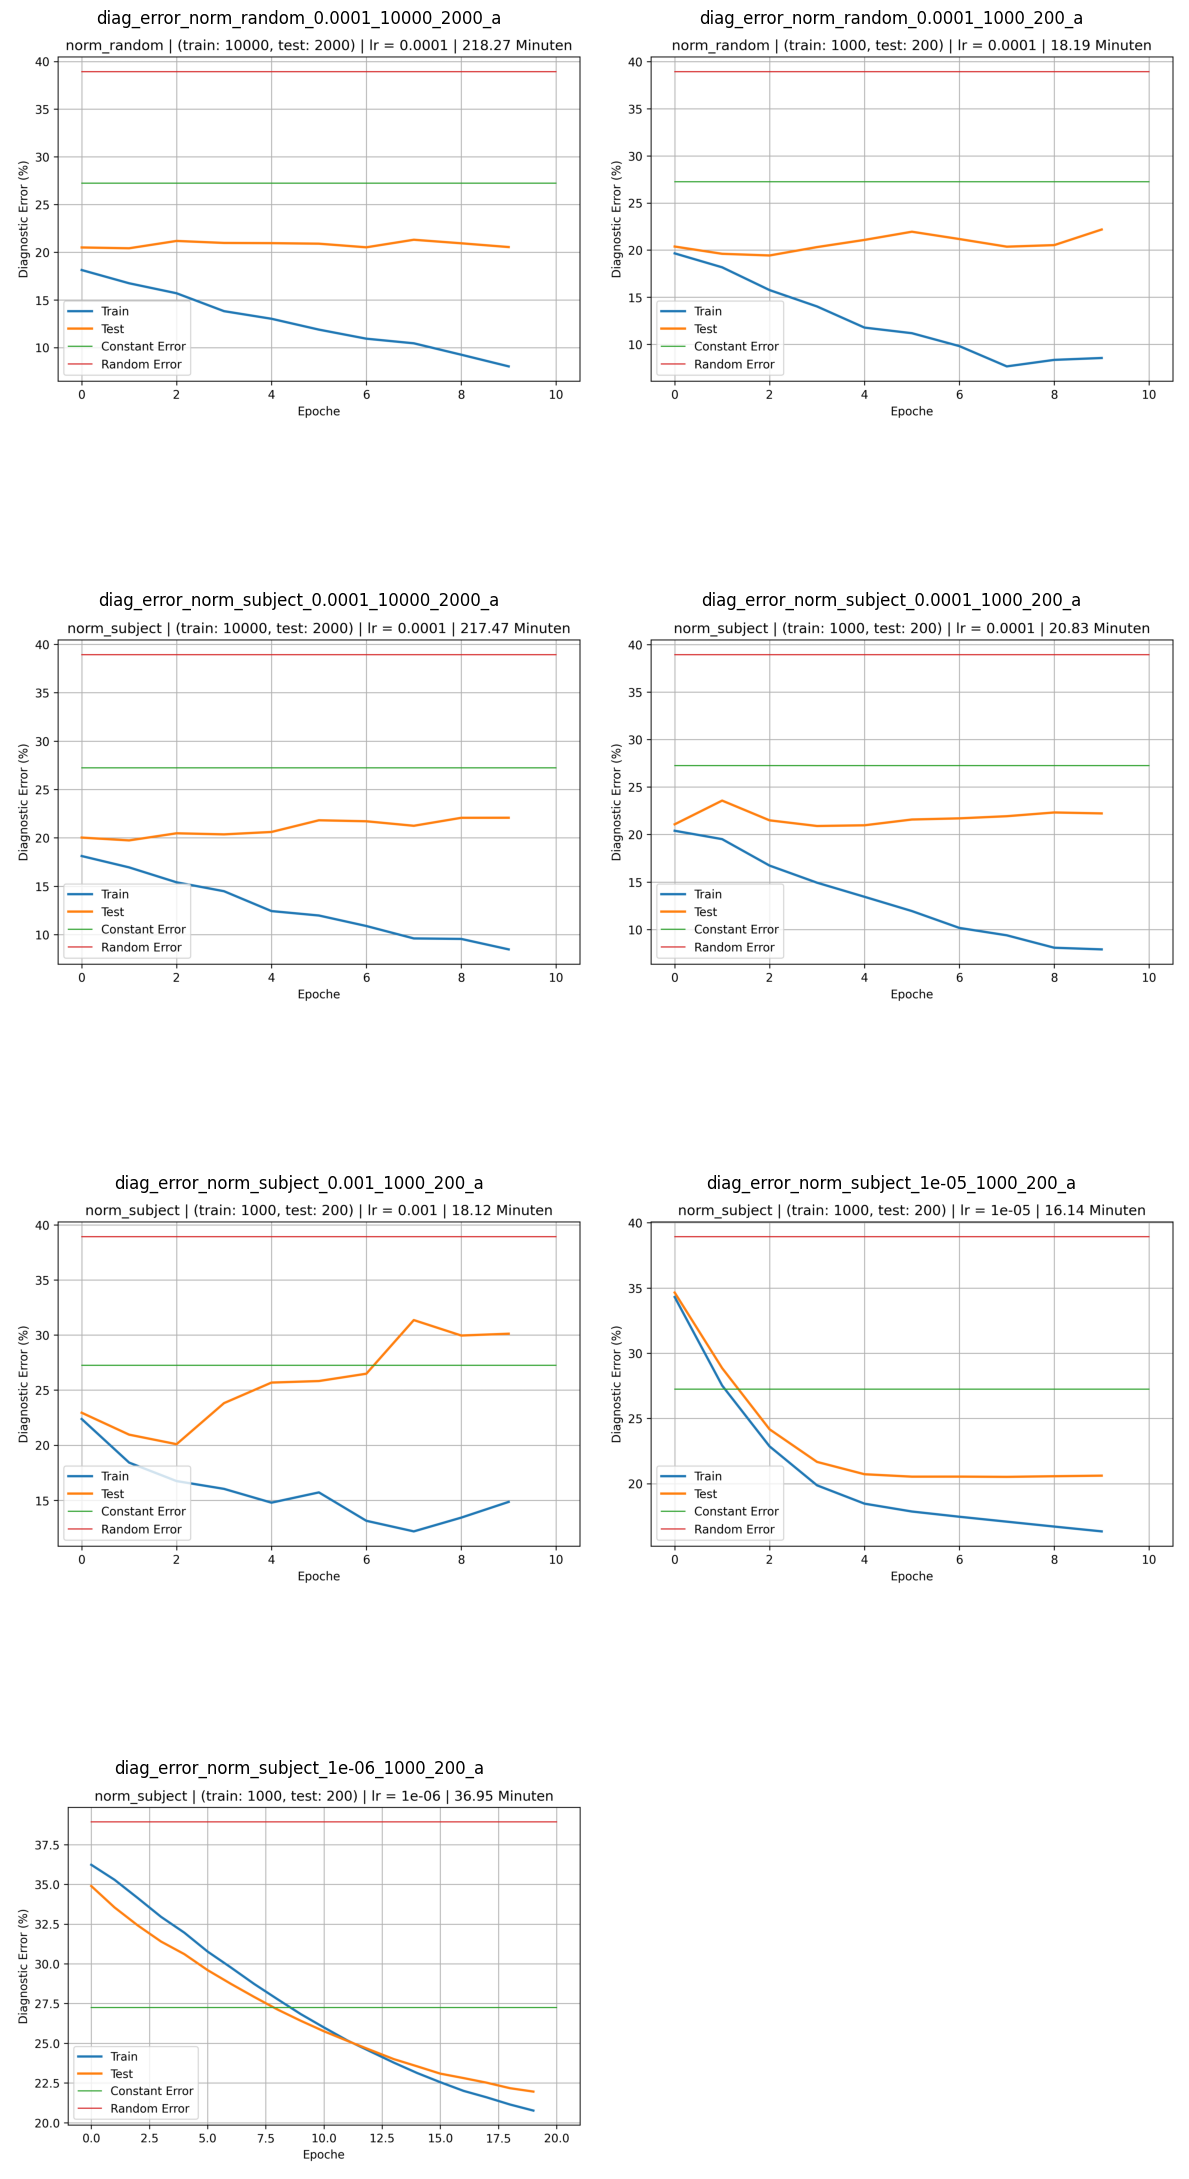

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_path = Path("./results")

images = sorted(result_path.glob("*.png"))

cols = 2
rows = (len(images) + cols - 1) // cols

plt.figure(figsize=(12, 6 * rows))

for i, img_path in enumerate(images):

    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.stem)

plt.tight_layout()
plt.show()

# ============== Evaluation ============= #

In [104]:
# ---------- Evaluation ----------

saved_model_name = './models/ResNet_best_test-model_only Sigmoid_norm_subject_1000-200.path'

checkpoint = torch.load(
    saved_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()


print(f"Test: \n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test: 

MAE : 0.2353 	 RMSE: 0.2829 
Diagonal-Error %: 20.0010 %
test_diag_error=20.0010% 


In [105]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    "results/baseline_predictions.csv",
    index=False
)



In [106]:
# Test:
print(results_df.head(10))

print(f"\n Anzahl Ergebnisse: {len(results_df)}\n\n")

print(results_df.shape)


       gt_x      gt_y    pred_x    pred_y
0  0.609727  0.246337  0.479492  0.490644
1  0.609727  0.246337  0.480538  0.488266
2  0.609727  0.246337  0.477189  0.489726
3  0.609727  0.246337  0.479119  0.489717
4  0.113634  0.162799  0.478432  0.491500
5  0.113634  0.162799  0.477581  0.494179
6  0.113634  0.162799  0.476946  0.490831
7  0.113634  0.162799  0.480299  0.491358
8  0.113634  0.162799  0.479158  0.493196
9  0.389503  0.616551  0.482786  0.495367

 Anzahl Ergebnisse: 200


(200, 4)


# ---------- Visualization ----------

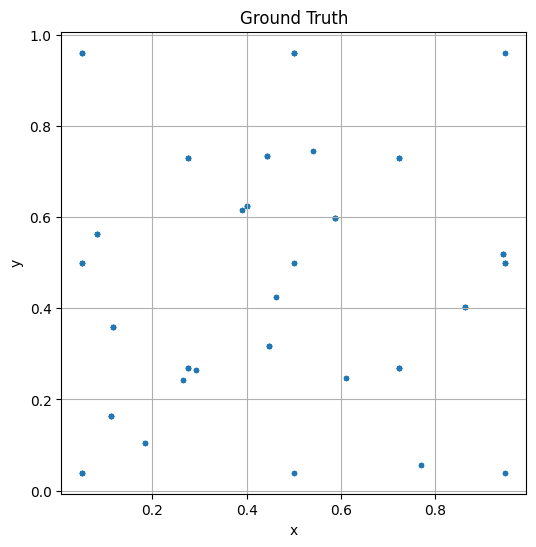

In [113]:
# ---------- Visualization ----------

vis = GazeVisualizer()

vis.plot_ground_truth(targets)



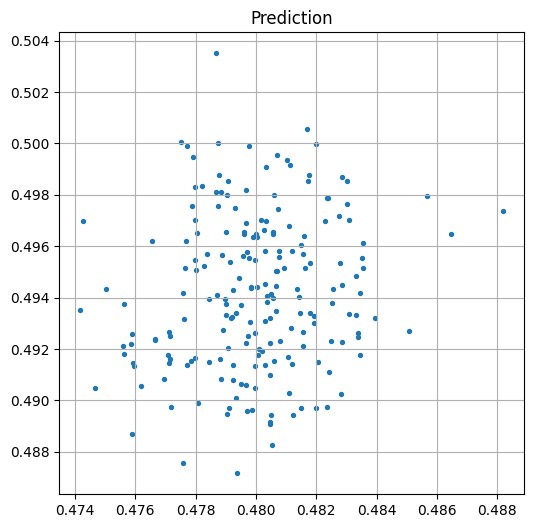

In [114]:
vis.plot_predictions(predictions)


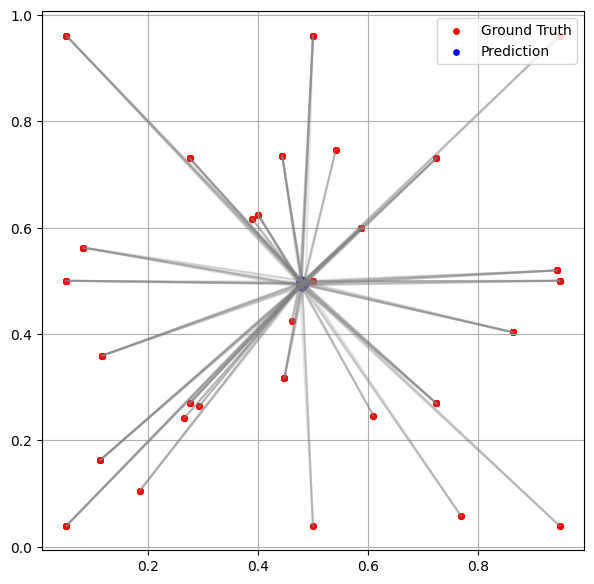

In [115]:
vis.plot_comparison(predictions, targets)



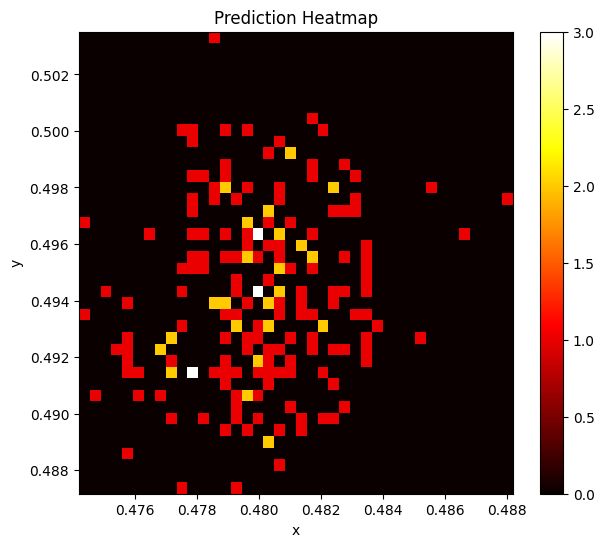

In [116]:
vis.plot_heatmap(predictions)


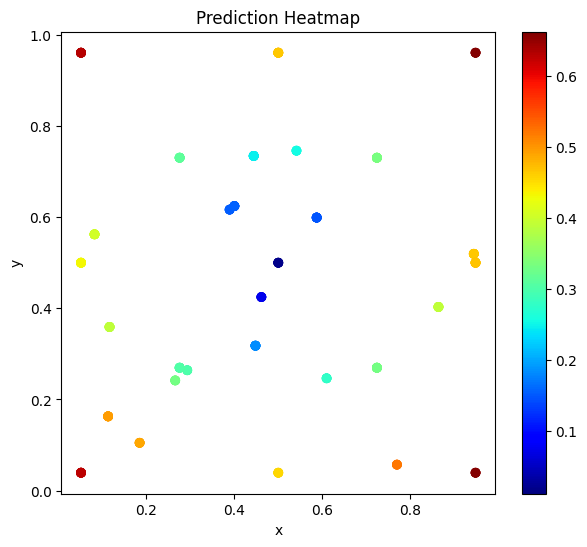

In [117]:
vis.plot_error_heatmap(
    predictions,
    targets,
    errors
)


In [129]:
# vis.animate_predictions(
#     predictions,
#     targets
# )

In [ ]:
# Inference
model.load_state_dict(
    torch.load(
        "gaze_model.pth"
    )
)

model.eval()

In [ ]:
predictions = []
targets_all = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)
        preds = model(images)

        predictions.append(
            preds.cpu()
        )

        targets_all.append(
            targets
        )


predictions = torch.cat(
    predictions
)

targets_all = torch.cat(
    targets_all
)
